In [12]:
import os
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [13]:
csv_path = 'all_paths_metadata_df.csv'
metadata_df = pd.read_csv(csv_path)
metadata_df = metadata_df.head()
metadata_df

,filepath,mode,height,width,format,directory,file_name,lesion_id,image_id,dx,dx_type,age,sex,localization,label
0,dataset_HAM10000/HAM10000_images_part_1/ISIC_0...,RGB,450,600,JPEG,HAM10000_images_part_1,ISIC_0024306,HAM_0000550,ISIC_0024306,Melanocytic nevi,follow_up,45.0,male,trunk,1
1,dataset_HAM10000/HAM10000_images_part_1/ISIC_0...,RGB,450,600,JPEG,HAM10000_images_part_1,ISIC_0024307,HAM_0003577,ISIC_0024307,Melanocytic nevi,follow_up,50.0,male,lower extremity,1
2,dataset_HAM10000/HAM10000_images_part_1/ISIC_0...,RGB,450,600,JPEG,HAM10000_images_part_1,ISIC_0024308,HAM_0001477,ISIC_0024308,Melanocytic nevi,follow_up,55.0,female,trunk,1
3,dataset_HAM10000/HAM10000_images_part_1/ISIC_0...,RGB,450,600,JPEG,HAM10000_images_part_1,ISIC_0024309,HAM_0000484,ISIC_0024309,Melanocytic nevi,follow_up,40.0,male,trunk,1
4,dataset_HAM10000/HAM10000_images_part_1/ISIC_0...,RGB,450,600,JPEG,HAM10000_images_part_1,ISIC_0024310,HAM_0003350,ISIC_0024310,Melanoma,histo,60.0,male,chest,2


# Node features : ResNet features extraction

In [14]:
def preprocess_image(img_path, image_size=(224, 224)):
    img = Image.open(img_path)
    img = img.resize(image_size)
    img = transforms.ToTensor()(img)
    return img

def get_resnet_features(image_paths, verbose):
    resnet_model = models.resnet18(pretrained=True)
    resnet_model.eval()
    
    node_features = []
    for img_path in image_paths:
        img = preprocess_image(img_path)

        
        with torch.no_grad():
            features = resnet_model(img.unsqueeze(0))
            if verbose:
                print(img_path)
                print(img.shape)
                print("-------")
                print(features.shape)
            
        node_features.append(features.squeeze().numpy())
    
    node_features = torch.tensor(node_features)
    return node_features



In [23]:
image_paths = [path for path in metadata_df['filepath']]
node_features  = get_resnet_features(image_paths, verbose=False)

/Users/marguerite/workspace_DS/venv/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/marguerite/workspace_DS/venv/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


# Define edges

In [24]:
# Change the variable for indexing the edges
groupby_variable = "localization"

In [25]:
def get_edge_index(metadata_df, groupby_variable):
    metadata_groups = metadata_df.groupby(groupby_variable)
    edges = []
    for _, group in metadata_groups:
        image_indices = [image_paths.index(img_name) for img_name in group['filepath']]
        if len(image_indices) > 1:
            for i in range(len(image_indices)):
                for j in range(i+1, len(image_indices)):
                    edges.append((image_indices[i], image_indices[j]))
    # Convert to PyTorch tensor
    edge_indexes = torch.tensor(edges).t().contiguous()

    return edges, edge_indexes

def get_edge_features(metadata_df, edges):
    # Define edge features (e.g., similarity between images based on metadata)
    # For simplicity, let's assume edge features represent the difference in age between images
    edge_features = []
    for edge in edges:
        age_diff = abs(metadata_df.iloc[edge[0]]['age'] - metadata_df.iloc[edge[1]]['age'])
        edge_features.append(age_diff)
    # Convert to PyTorch tensor
    edge_features = torch.tensor(edge_features).unsqueeze(1)
    return edge_features
    

def encode_node_labels(metadata_df): 
    label_encoder = LabelEncoder()
    node_labels = label_encoder.fit_transform(metadata_df['dx'])
    return node_labels



In [26]:
# Create a PyTorch Geometric Data object
edges, edge_indexes = get_edge_index(metadata_df, groupby_variable)
edge_features = get_edge_features(metadata_df, edges)
node_labels = encode_node_labels(metadata_df)
data = Data(x=node_features, edge_index=edge_index, edge_attr=edge_features, y=node_labels)


# Plot adjacency matrix

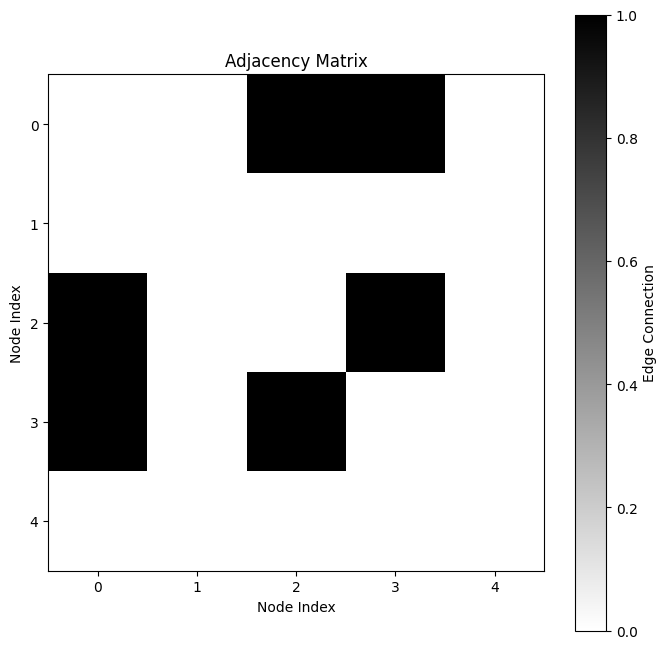

In [29]:
def plot_adjacency_matrix(node_features, edge_indexes):
    # edge_index is a tensor with shape (2, num_edges)
    # num_nodes is the total number of nodes
    num_nodes = len(node_features[:, 0])
    
    # Create an empty adjacency matrix
    adjacency_matrix = np.zeros((num_nodes, num_nodes))
    
    # Fill the adjacency matrix based on edge connections
    for i in range(edge_indexes.shape[1]):
        src, dst = edge_indexes[:, i]
        adjacency_matrix[src, dst] = 1
        adjacency_matrix[dst, src] = 1  # Assuming undirected graph
    
    # Plot the adjacency matrix
    plt.figure(figsize=(8, 8))
    plt.imshow(adjacency_matrix, cmap='binary', origin='upper')
    plt.title('Adjacency Matrix')
    plt.xlabel('Node Index')
    plt.ylabel('Node Index')
    plt.colorbar(label='Edge Connection')
    plt.show()

plot_adjacency_matrix(node_features, edge_indexes)

In [ ]:
# Check with metadata_df.head()
# Node 0 has the same localization 'trunk' than nodes [2, 3]
# Node 1 : localization "lower extremity" - not connected to other nodes 
# Node 4 : localization "chest" - not connected to other nodes 

# You can test with another groupby_variable
# We can also add different edges between nodes


In [30]:
metadata_df.head()


,filepath,mode,height,width,format,directory,file_name,lesion_id,image_id,dx,dx_type,age,sex,localization,label
0,dataset_HAM10000/HAM10000_images_part_1/ISIC_0...,RGB,450,600,JPEG,HAM10000_images_part_1,ISIC_0024306,HAM_0000550,ISIC_0024306,Melanocytic nevi,follow_up,45.0,male,trunk,1
1,dataset_HAM10000/HAM10000_images_part_1/ISIC_0...,RGB,450,600,JPEG,HAM10000_images_part_1,ISIC_0024307,HAM_0003577,ISIC_0024307,Melanocytic nevi,follow_up,50.0,male,lower extremity,1
2,dataset_HAM10000/HAM10000_images_part_1/ISIC_0...,RGB,450,600,JPEG,HAM10000_images_part_1,ISIC_0024308,HAM_0001477,ISIC_0024308,Melanocytic nevi,follow_up,55.0,female,trunk,1
3,dataset_HAM10000/HAM10000_images_part_1/ISIC_0...,RGB,450,600,JPEG,HAM10000_images_part_1,ISIC_0024309,HAM_0000484,ISIC_0024309,Melanocytic nevi,follow_up,40.0,male,trunk,1
4,dataset_HAM10000/HAM10000_images_part_1/ISIC_0...,RGB,450,600,JPEG,HAM10000_images_part_1,ISIC_0024310,HAM_0003350,ISIC_0024310,Melanoma,histo,60.0,male,chest,2
